In [2]:
# # Fas 2: EDA & Datarensning — Örebro Bostadsprisanalys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Stil
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Paket laddade!')

Paket laddade!


In [3]:
# Ladda Hemnet-data
df = pd.read_csv('../data/raw/hemnet_orebro_fixed.csv')
print(f'Rader: {len(df)}')
print(f'Kolumner: {list(df.columns)}')
display(df.head())

Rader: 6622
Kolumner: ['slutpris', 'avgift_kr', 'boarea_kvm', 'antal_rum', 'sald_datum', 'prisforandring_pct', 'pris_per_kvm', 'omrade', 'url', 'bostadstyp', 'raw_text']


,slutpris,avgift_kr,boarea_kvm,antal_rum,sald_datum,prisforandring_pct,pris_per_kvm,omrade,url,bostadstyp,raw_text
0,2700000,8768.0,117.0,4.0,2026-03-13,8.0,23077.0,Lägenhet Rynninge,https://www.hemnet.se/salda/lagenhet-4rum-rynn...,lagenheter,Såld 13 mar. 2026 Kaserngården 14 Lägenhet Ryn...
1,1670000,5490.0,84.0,3.0,2026-03-11,1.0,19881.0,Lägenhet Hovsta,https://www.hemnet.se/salda/lagenhet-3rum-hovs...,lagenheter,Såld 11 mar. 2026 Lövskogsvägen 17 Lägenhet Ho...
2,1795000,2790.0,44.0,1.0,2026-03-11,-10.0,40795.0,Lägenhet Centralt Öster,https://www.hemnet.se/salda/lagenhet-1rum-cent...,lagenheter,Såld 11 mar. 2026 Förmansgatan 8 Lägenhet Cent...
3,1380000,4906.0,53.0,2.0,2026-03-11,-1.0,26038.0,B Lägenhet Sörby,https://www.hemnet.se/salda/lagenhet-2rum-sorb...,lagenheter,Såld 11 mar. 2026 Hagmarksgatan 11B Lägenhet S...
4,1000000,4603.0,78.5,3.0,2026-03-11,-9.0,12739.0,Lägenhet Lundby,https://www.hemnet.se/salda/lagenhet-3rum-lund...,lagenheter,Såld 11 mar. 2026 Mandelstensvägen 95 Lägenhet...


In [4]:
# Snabb översikt
print('=== SAKNADE VÄRDEN ===')
missing = df.isnull().sum()
print(missing[missing > 0])

print(f'\n=== BOSTADSTYPER ===')
print(df['bostadstyp'].value_counts())

print(f'\n=== GRUNDSTATISTIK ===')
display(df[['slutpris', 'boarea_kvm', 'antal_rum', 'avgift_kr']].describe())

=== SAKNADE VÄRDEN ===
avgift_kr             2864
boarea_kvm               5
antal_rum              108
prisforandring_pct      40
pris_per_kvm          2903
omrade                  30
dtype: int64

=== BOSTADSTYPER ===
bostadstyp
lagenheter    2500
villor        2497
radhus        1625
Name: count, dtype: int64

=== GRUNDSTATISTIK ===


,slutpris,boarea_kvm,antal_rum,avgift_kr
count,6.622000e+03,6617.000000,6514.000000,3758.000000
mean,2.796085e+06,104.700559,4.017578,4836.742416
std,1.557041e+06,52.900187,1.608301,1339.633745
min,1.100000e+05,15.000000,1.000000,556.000000
25%,1.670000e+06,75.000000,3.000000,3971.250000
50%,2.407500e+06,100.000000,4.000000,4817.000000
75%,3.550000e+06,124.000000,5.000000,5651.000000
max,1.400000e+07,990.000000,13.000000,11720.000000


In [5]:
## 2. Datarensning
# 2a. Konvertera datum
df['sald_datum'] = pd.to_datetime(df['sald_datum'], errors='coerce')
df['sald_ar'] = df['sald_datum'].dt.year
df['sald_manad'] = df['sald_datum'].dt.month
df['sald_kvartal'] = df['sald_datum'].dt.quarter

print('Datumintervall:')
print(f'  Från: {df["sald_datum"].min()}')
print(f'  Till: {df["sald_datum"].max()}')
print(f'\nÅr-fördelning:')
print(df['sald_ar'].value_counts().sort_index())

Datumintervall:
  Från: 2013-01-30 00:00:00
  Till: 2026-03-13 00:00:00

År-fördelning:
sald_ar
2013      70
2014     116
2015      78
2016      56
2017      66
2018      75
2019     137
2020     594
2021     625
2022     798
2023    1198
2024    1302
2025    1321
2026     186
Name: count, dtype: int64


In [6]:
# 2b. Fyll i saknade pris_per_kvm
# Beräkna från slutpris / boarea där det saknas
mask = df['pris_per_kvm'].isna() & df['boarea_kvm'].notna() & (df['boarea_kvm'] > 0)
df.loc[mask, 'pris_per_kvm'] = (df.loc[mask, 'slutpris'] / df.loc[mask, 'boarea_kvm']).round(0)

print(f'pris_per_kvm saknas nu: {df["pris_per_kvm"].isna().sum()} (var 2903)')

pris_per_kvm saknas nu: 5 (var 2903)


In [7]:
# 2c. Hantera avgift_kr — villor har ingen avgift
# Sätt avgift till 0 för villor (de har driftkostnad istället)
df.loc[df['bostadstyp'] == 'villor', 'avgift_kr'] = df.loc[df['bostadstyp'] == 'villor', 'avgift_kr'].fillna(0)

print('Avgift saknas per bostadstyp:')
print(df.groupby('bostadstyp')['avgift_kr'].apply(lambda x: x.isna().sum()))

Avgift saknas per bostadstyp:
bostadstyp
lagenheter      1
radhus        384
villor          0
Name: avgift_kr, dtype: int64


In [8]:
# 2d. Ta bort outliers
before = len(df)

# Rimliga gränser för Örebro
df = df[df['slutpris'] >= 100_000]          # Minst 100k
df = df[df['slutpris'] <= 15_000_000]        # Max 15M
df = df[df['boarea_kvm'].between(10, 400) | df['boarea_kvm'].isna()]  # 10-400 m²
df = df[df['antal_rum'].between(1, 12) | df['antal_rum'].isna()]      # 1-12 rum

print(f'Borttagna outliers: {before - len(df)}')
print(f'Kvarvarande rader: {len(df)}')

Borttagna outliers: 22
Kvarvarande rader: 6600


In [9]:
# 2e. Rensa område-kolumnen
# Ta bort "Lägenhet", "Villa", "Radhus" prefix från område
df['omrade_clean'] = df['omrade'].str.replace(r'^(Lägenhet|Villa|Radhus|[A-Z]\s)', '', regex=True).str.strip()
df['omrade_clean'] = df['omrade_clean'].str.replace(r'^\s+', '', regex=True)

# Visa vanligaste områdena
print('Topp 15 områden:')
print(df['omrade_clean'].value_counts().head(15))

Topp 15 områden:
omrade_clean
Örebro           332
Adolfsberg       325
Almby            277
Sörbyängen       244
Hovsta           157
Mellringe        152
Lundby           146
Sörby            121
Solhaga          113
Nya Hjärsta      106
Glanshammar       97
Lillån            90
Öster             87
Stora Mellösa     86
Vintrosa          82
Name: count, dtype: int64


In [ ]:
## Fas 3. Feature Engineering
# 3a. Prisrelaterade features
df['kvm_per_rum'] = (df['boarea_kvm'] / df['antal_rum']).round(1)
df['avgift_per_kvm'] = (df['avgift_kr'] / df['boarea_kvm']).round(1)
df['avgift_andel'] = ((df['avgift_kr'] * 12) / df['slutpris'] * 100).round(2)

print('Nya features skapade:')
print(f'  kvm_per_rum:   median {df["kvm_per_rum"].median():.1f}')
print(f'  avgift_per_kvm: median {df["avgift_per_kvm"].median():.1f}')
print(f'  avgift_andel:   median {df["avgift_andel"].median():.2f}%')

Nya features skapade:
  kvm_per_rum:   median 26.0
  avgift_per_kvm: median 45.2
  avgift_andel:   median 2.07%


In [11]:
# 3b. Tidsbaserade features
df['sasong'] = df['sald_manad'].map({
    1: 'vinter', 2: 'vinter', 3: 'vår',
    4: 'vår', 5: 'vår', 6: 'sommar',
    7: 'sommar', 8: 'sommar', 9: 'höst',
    10: 'höst', 11: 'höst', 12: 'vinter'
})

print('Försäljningar per säsong:')
print(df['sasong'].value_counts())

Försäljningar per säsong:
sasong
höst      1891
vår       1803
sommar    1466
vinter    1440
Name: count, dtype: int64


In [12]:
# 3c. Budkrig-feature
df['budkrig'] = (df['prisforandring_pct'] > 0).astype(int)
df['prissankt'] = (df['prisforandring_pct'] < 0).astype(int)

print(f'Andel budkrig (pris gick upp):  {df["budkrig"].mean()*100:.1f}%')
print(f'Andel prissänkt (pris gick ner): {df["prissankt"].mean()*100:.1f}%')

Andel budkrig (pris gick upp):  38.7%
Andel prissänkt (pris gick ner): 42.8%


In [13]:
# 3d. Storlekskategori
df['storlek_kategori'] = pd.cut(
    df['boarea_kvm'],
    bins=[0, 40, 60, 80, 100, 150, 500],
    labels=['mini (<40)', 'liten (40-60)', 'medel (60-80)', 
            'stor (80-100)', 'xl (100-150)', 'xxl (150+)']
)

print('Storleksfördelning:')
print(df['storlek_kategori'].value_counts().sort_index())

Storleksfördelning:
storlek_kategori
mini (<40)        208
liten (40-60)     654
medel (60-80)    1327
stor (80-100)    1154
xl (100-150)     2485
xxl (150+)        767
Name: count, dtype: int64


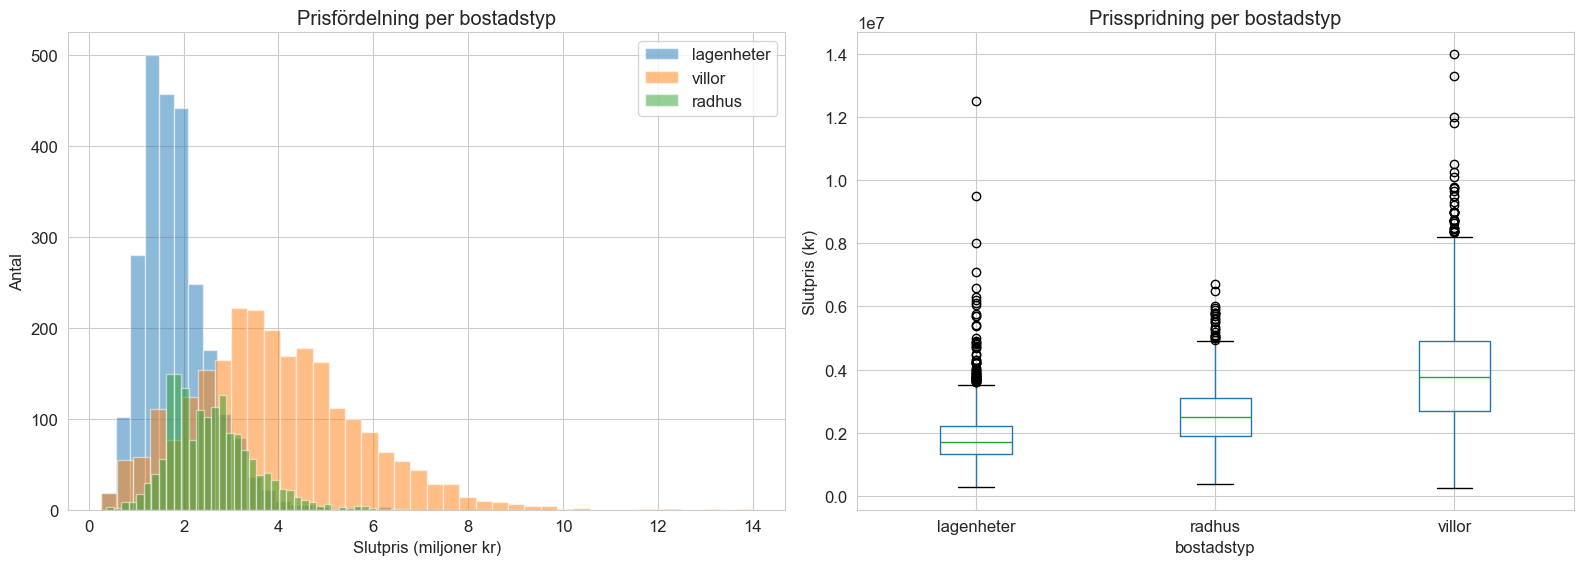


Medianpris per bostadstyp:
bostadstyp
villor        3,750,000 kr
radhus        2,495,000 kr
lagenheter    1,700,000 kr
Name: slutpris, dtype: str


In [14]:
## 4. EDA — Utforska mönster
# 4a. Prisfördelning per bostadstyp
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
for typ in df['bostadstyp'].unique():
    subset = df[df['bostadstyp'] == typ]
    axes[0].hist(subset['slutpris'] / 1e6, bins=40, alpha=0.5, label=typ)
axes[0].set_xlabel('Slutpris (miljoner kr)')
axes[0].set_ylabel('Antal')
axes[0].set_title('Prisfördelning per bostadstyp')
axes[0].legend()

# Boxplot
df.boxplot(column='slutpris', by='bostadstyp', ax=axes[1])
axes[1].set_ylabel('Slutpris (kr)')
axes[1].set_title('Prisspridning per bostadstyp')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Statistik per typ
print('\nMedianpris per bostadstyp:')
print(df.groupby('bostadstyp')['slutpris'].median().sort_values(ascending=False).apply(lambda x: f'{x:,.0f} kr'))

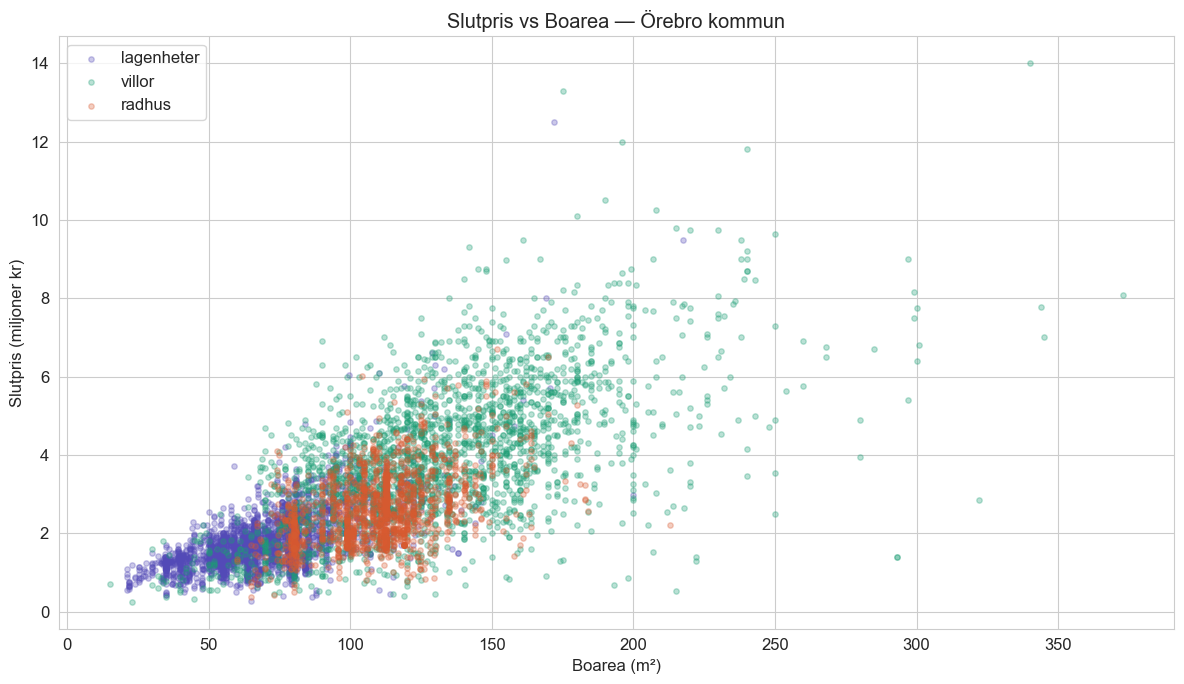

In [15]:
# 4b. Pris vs Boarea — scatter plot
fig, ax = plt.subplots(figsize=(12, 7))

colors = {'lagenheter': '#534AB7', 'villor': '#1D9E75', 'radhus': '#D85A30'}

for typ in df['bostadstyp'].unique():
    subset = df[df['bostadstyp'] == typ]
    ax.scatter(subset['boarea_kvm'], subset['slutpris'] / 1e6, 
               alpha=0.3, s=15, label=typ, color=colors.get(typ, 'gray'))

ax.set_xlabel('Boarea (m²)')
ax.set_ylabel('Slutpris (miljoner kr)')
ax.set_title('Slutpris vs Boarea — Örebro kommun')
ax.legend()
plt.tight_layout()
plt.show()

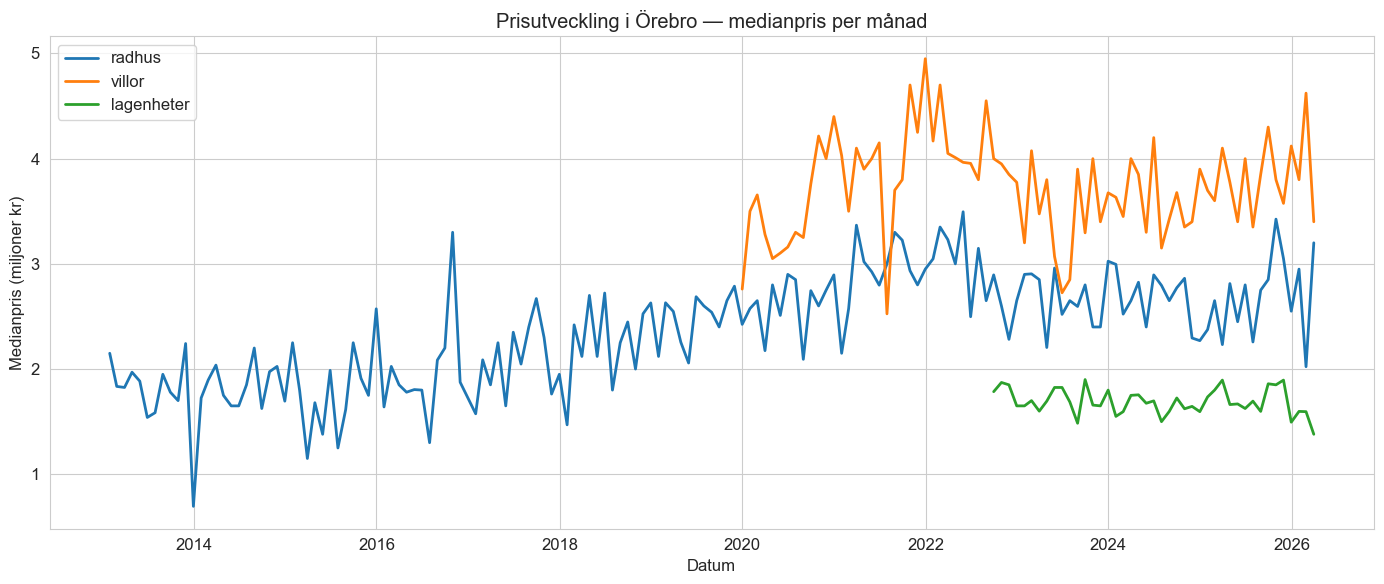

In [16]:
# 4c. Pristrend över tid
monthly = df.groupby([pd.Grouper(key='sald_datum', freq='ME'), 'bostadstyp'])['slutpris'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for typ in monthly['bostadstyp'].unique():
    subset = monthly[monthly['bostadstyp'] == typ]
    ax.plot(subset['sald_datum'], subset['slutpris'] / 1e6, label=typ, linewidth=2)

ax.set_xlabel('Datum')
ax.set_ylabel('Medianpris (miljoner kr)')
ax.set_title('Prisutveckling i Örebro — medianpris per månad')
ax.legend()
plt.tight_layout()
plt.show()

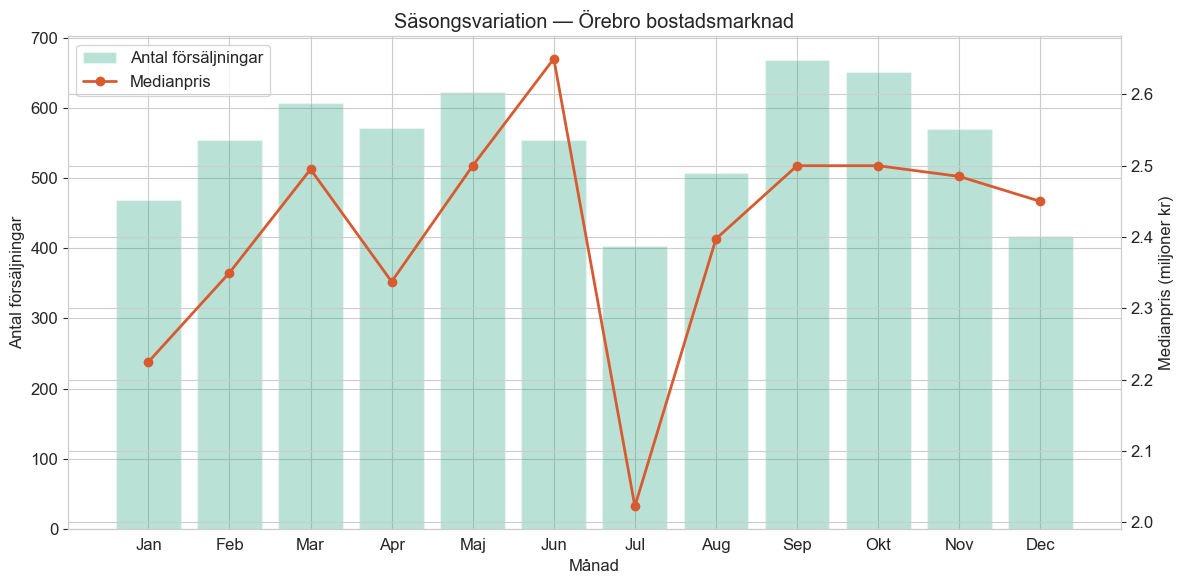

In [17]:
# 4d. Säsongsvariation
seasonal = df.groupby('sald_manad').agg(
    medianpris=('slutpris', 'median'),
    antal=('slutpris', 'count')
).reset_index()

months = ['Jan','Feb','Mar','Apr','Maj','Jun','Jul','Aug','Sep','Okt','Nov','Dec']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.bar(range(1,13), seasonal['antal'], alpha=0.3, color='#1D9E75', label='Antal försäljningar')
ax2.plot(range(1,13), seasonal['medianpris'] / 1e6, 'o-', color='#D85A30', linewidth=2, label='Medianpris')

ax1.set_xlabel('Månad')
ax1.set_ylabel('Antal försäljningar')
ax2.set_ylabel('Medianpris (miljoner kr)')
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(months)
ax1.set_title('Säsongsvariation — Örebro bostadsmarknad')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

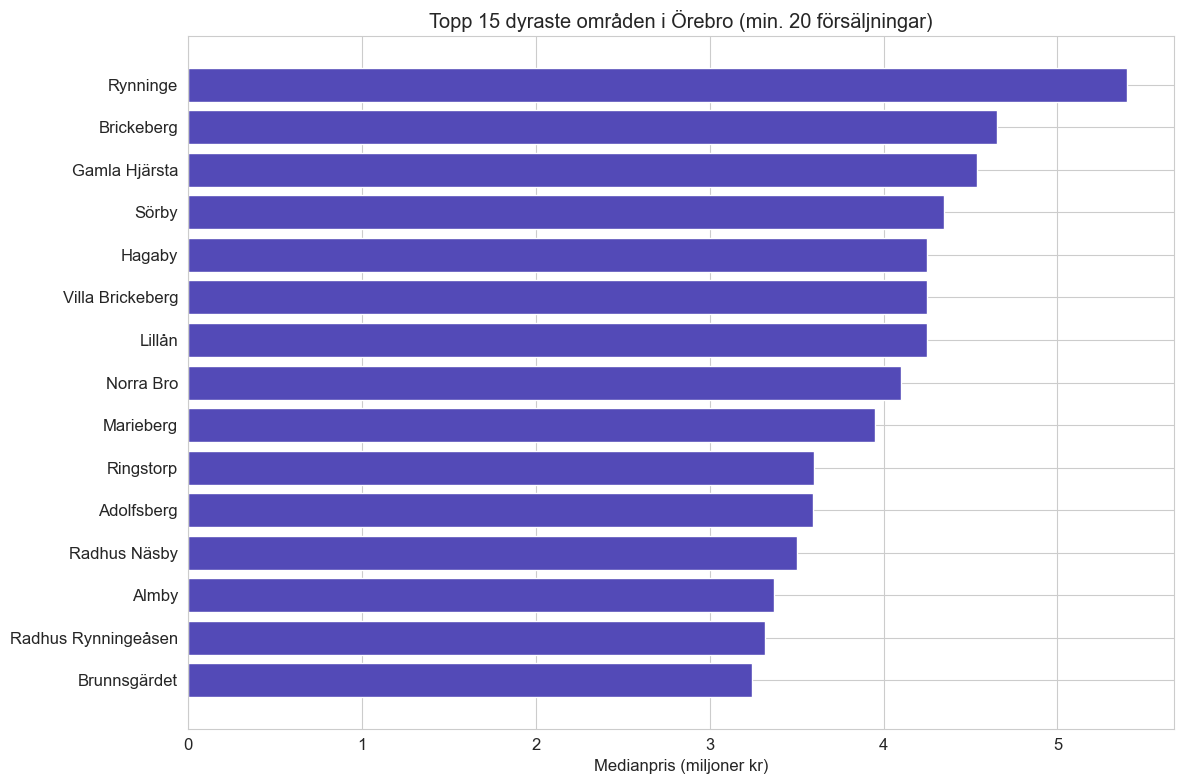


Statistik per område:


,omrade_clean,medianpris,antal,median_kvm
388,Rynninge,5400000.0,37,39157.0
34,Brickeberg,4650000.0,31,32500.0
117,Gamla Hjärsta,4540000.0,42,35782.5
429,Sörby,4350000.0,121,39506.0
134,Hagaby,4250000.0,40,34207.0
450,Villa Brickeberg,4250000.0,21,31481.0
176,Lillån,4247500.0,90,33126.0
282,Norra Bro,4100000.0,40,28169.0
265,Marieberg,3950000.0,63,33854.0
382,Ringstorp,3600000.0,35,36867.0


In [18]:
# 4e. Topp 15 områden efter medianpris
area_stats = df.groupby('omrade_clean').agg(
    medianpris=('slutpris', 'median'),
    antal=('slutpris', 'count'),
    median_kvm=('pris_per_kvm', 'median')
).reset_index()

# Minst 20 försäljningar
area_stats = area_stats[area_stats['antal'] >= 20]
top_areas = area_stats.nlargest(15, 'medianpris')

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_areas['omrade_clean'], top_areas['medianpris'] / 1e6, color='#534AB7')
ax.set_xlabel('Medianpris (miljoner kr)')
ax.set_title('Topp 15 dyraste områden i Örebro (min. 20 försäljningar)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nStatistik per område:')
display(top_areas.sort_values('medianpris', ascending=False))

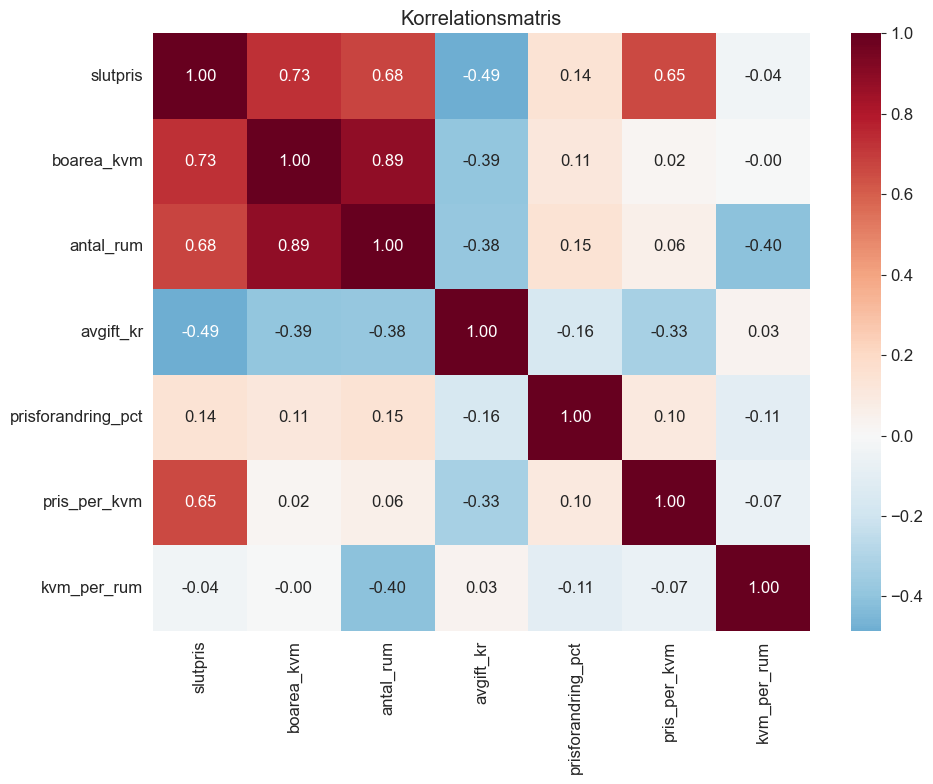


Starkaste korrelationer med slutpris:
boarea_kvm            0.732591
antal_rum             0.679789
pris_per_kvm          0.654312
prisforandring_pct    0.141958
kvm_per_rum          -0.035988
avgift_kr            -0.485313
Name: slutpris, dtype: float64


In [19]:
# 4f. Korrelationsmatris
numeric_cols = ['slutpris', 'boarea_kvm', 'antal_rum', 'avgift_kr', 
                'prisforandring_pct', 'pris_per_kvm', 'kvm_per_rum']
available = [c for c in numeric_cols if c in df.columns]

corr = df[available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Korrelationsmatris')
plt.tight_layout()
plt.show()

print('\nStarkaste korrelationer med slutpris:')
print(corr['slutpris'].sort_values(ascending=False)[1:])

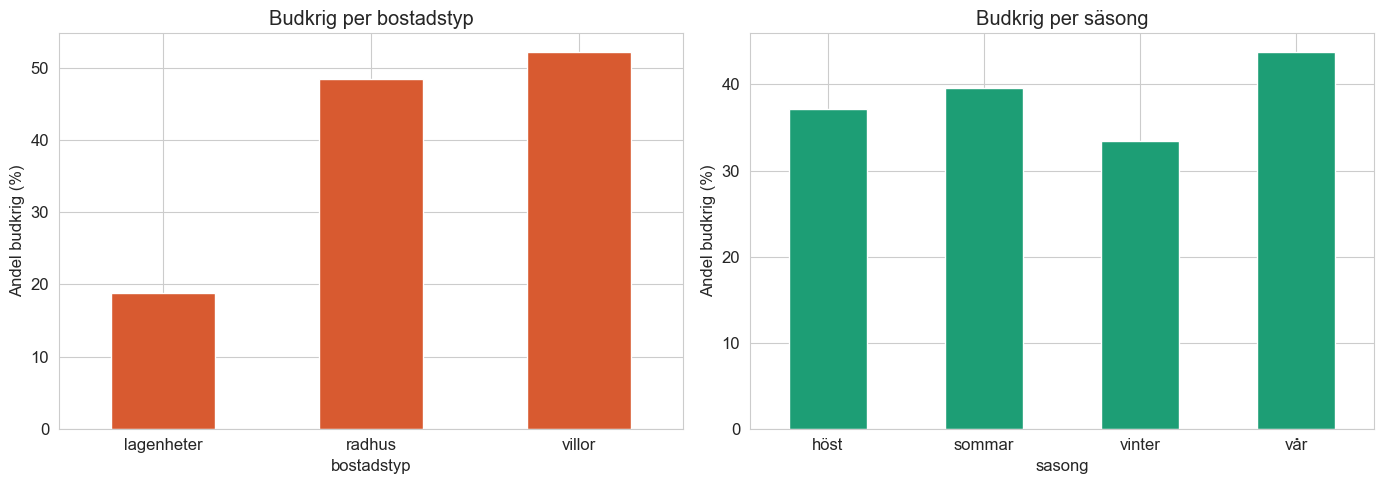

In [20]:
# 4g. Budkrig-analys
budkrig_per_typ = df.groupby('bostadstyp')['budkrig'].mean() * 100
budkrig_per_sasong = df.groupby('sasong')['budkrig'].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

budkrig_per_typ.plot(kind='bar', ax=ax1, color='#D85A30')
ax1.set_ylabel('Andel budkrig (%)')
ax1.set_title('Budkrig per bostadstyp')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

budkrig_per_sasong.plot(kind='bar', ax=ax2, color='#1D9E75')
ax2.set_ylabel('Andel budkrig (%)')
ax2.set_title('Budkrig per säsong')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [21]:
## 5. Spara processad data
# Spara den rensade och berikade datan
output_path = '../data/processed/orebro_housing_clean.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'Processad data sparad!')
print(f'  Fil: {output_path}')
print(f'  Rader: {len(df)}')
print(f'  Kolumner: {len(df.columns)}')
print(f'\nKolumner:')
print(list(df.columns))

print(f'\n=== KLAR FÖR FAS 3: MODELLERING ===')

Processad data sparad!
  Fil: ../data/processed/orebro_housing_clean.csv
  Rader: 6600
  Kolumner: 22

Kolumner:
['slutpris', 'avgift_kr', 'boarea_kvm', 'antal_rum', 'sald_datum', 'prisforandring_pct', 'pris_per_kvm', 'omrade', 'url', 'bostadstyp', 'raw_text', 'sald_ar', 'sald_manad', 'sald_kvartal', 'omrade_clean', 'kvm_per_rum', 'avgift_per_kvm', 'avgift_andel', 'sasong', 'budkrig', 'prissankt', 'storlek_kategori']

=== KLAR FÖR FAS 3: MODELLERING ===
